# RescueLink AI - Training & Evaluation Notebook
This notebook trains and evaluates the emergency classification model, visualizes accuracy, and saves artifacts.
This notebook will guide you step by step:
1. Load the dataset
2. Tokenize the text
3. Train the model
4. Evaluate accuracy
5. Visualize results



In [1]:
# Standard library
import os
import ast
import json

# Data handling
import pandas as pd
import numpy as np

# PyTorch
import torch
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers (multilingual backbone + tokenizer)
from transformers import AutoTokenizer

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support
)

# Project modules
from models.emergency_classifier import EmergencyClassifier
from training.train import EmergencyDataset

ModuleNotFoundError: No module named 'matplotlib'

## Step 0: Load Latest Trained Model

Before training, we check if a saved model file (`models/emergency_model.pt`) exists.  
- If it does, we load the weights into our `EmergencyClassifier` so we can continue training or run inference without starting from scratch.  
- If not, we initialize a fresh model.


In [2]:
import json

MODEL_PATH = "models/emergency_model.pt"
META_PATH = "models/label_meta.json"

def load_metadata():
    if os.path.exists(META_PATH):
        with open(META_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return {
            "incident_type_labels": checkpoint.get("incident_type_labels"),
            "severity_labels": checkpoint.get("severity_labels"),
            "backbone": checkpoint.get("backbone", "xlm-roberta-base"),
            "threshold": checkpoint.get("threshold", 0.5),
        }
    raise ValueError("Metadata not found. Retrain to regenerate checkpoint + label_meta.json.")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("No saved model found, train first to create models/emergency_model.pt")

meta = load_metadata()
tokenizer = AutoTokenizer.from_pretrained(meta.get("backbone", "xlm-roberta-base"))

model = EmergencyClassifier(
    num_incident_types=len(meta["incident_type_labels"]),
    num_severity_classes=len(meta["severity_labels"]),
    backbone=meta.get("backbone", "xlm-roberta-base"),
)

checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint.get("model_state_dict") if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

print("Loaded model with:")
print(f"- backbone: {meta.get('backbone', 'xlm-roberta-base')}")
print(f"- incident types: {meta['incident_type_labels']}")
print(f"- severity labels: {meta['severity_labels']}")

Loaded model with:
- backbone: xlm-roberta-base
- incident types: ['Fire', 'Crime', 'Accident', 'Medical', 'Natural Disaster', 'Other']
- severity labels: ['Green', 'Yellow', 'Red', 'Black']


## Step 1: Load the Dataset
Run the next cell to load the emergency dataset from `data/emergency_dataset.csv`.
We’ll split it into training and validation sets.


In [7]:
# Load the unified dataset generated by generate_dataset.py
df = pd.read_csv("data/emergency_dataset.csv")

# Parse string representations back to lists
df["incident_types"] = df["incident_types"].apply(ast.literal_eval)
df["type_labels"] = df["type_labels"].apply(ast.literal_eval)

# Ensure severity_label is integer
df["severity_label"] = df["severity_label"].astype(int)

# Split into train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Sample type_labels:", train_df["type_labels"].iloc[0])
print("Sample severity_label:", train_df["severity_label"].iloc[0], "Type:", type(train_df["severity_label"].iloc[0]))


Train size: 4800
Validation size: 1200
Sample type_labels: [1, 2]
Sample severity_label: 0 Type: <class 'numpy.int64'>


## Step 2: Tokenization
Run this cell to convert text into numerical tokens using DistilBERT’s tokenizer.
This prepares the data for the model.


In [8]:
# Use XLM-RoBERTa tokenizer for multilingual support
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Tokenize training and validation sets
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)
val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [9]:
# Note: use "type_labels" (plural) since each row may have multiple incident types
train_dataset = EmergencyDataset(
    train_encodings, 
    train_df["type_labels"].tolist(), 
    train_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"])
)
val_dataset = EmergencyDataset(
    val_encodings, 
    val_df["type_labels"].tolist(), 
    val_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"])
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

## Step 3: Training Loop
Run this cell to train the EmergencyClassifier model.
You’ll see training and validation loss after each epoch.


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a fresh model with correct parameters
model = EmergencyClassifier(
    num_incident_types=len(meta["incident_type_labels"]),
    num_severity_classes=len(meta["severity_labels"]),
    backbone=meta.get("backbone", "xlm-roberta-base"),
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Add scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

train_losses, val_losses = [], []

# Loss functions
bce_loss = torch.nn.BCEWithLogitsLoss()                     # multi-label incident types
ce_loss_severity = torch.nn.CrossEntropyLoss(label_smoothing=0.1)  # severity with smoothing

num_incident_types = len(meta["incident_type_labels"])

for epoch in range(5):  # increase epochs to see scheduler effect
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask)

        # Multi-label incident type loss
        loss_type = bce_loss(outputs["type_logits"], labels[:,0:num_incident_types].float())

        # Severity loss with label smoothing
        loss_severity = ce_loss_severity(outputs["severity_logits"], labels[:,num_incident_types].long())

        # Total loss
        loss = loss_type + loss_severity
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            loss_type = bce_loss(outputs["type_logits"], labels[:,0:num_incident_types].float())
            loss_severity = ce_loss_severity(outputs["severity_logits"], labels[:,num_incident_types].long())
            val_loss += (loss_type + loss_severity).item()
    val_losses.append(val_loss)

    # Step the scheduler
    scheduler.step()

    print(f"Epoch {epoch+1} | LR: {scheduler.get_last_lr()[0]:.6f} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1 | LR: 0.000050 | Train Loss: 382.1194 | Val Loss: 73.4999
Epoch 2 | LR: 0.000005 | Train Loss: 290.8293 | Val Loss: 71.5082
Epoch 3 | LR: 0.000005 | Train Loss: 283.2973 | Val Loss: 69.3780
Epoch 4 | LR: 0.000001 | Train Loss: 265.0959 | Val Loss: 60.6829
Epoch 5 | LR: 0.000001 | Train Loss: 245.0910 | Val Loss: 59.9238


## Step 4: Accuracy & Metrics
Run this cell to evaluate the model on the validation set.
You’ll see precision, recall, and F1 scores.


In [11]:
y_true_types, y_true_severity = [], []
y_pred_types, y_pred_severity = [], []

num_incident_types = len(meta["incident_type_labels"])

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()
        outputs = model(input_ids, attention_mask)

        # Multi-label incident type predictions
        type_probs = torch.sigmoid(outputs["type_logits"]).cpu().numpy()
        preds_type = (type_probs >= 0.5).astype(int)  # threshold at 0.5

        # Severity predictions (single-label)
        preds_severity = torch.argmax(outputs["severity_logits"], dim=1).cpu().numpy()

        # Collect ground truth
        y_true_types.extend(labels[:,0:num_incident_types])
        y_true_severity.extend(labels[:,-1])
        y_pred_types.extend(preds_type)
        y_pred_severity.extend(preds_severity)

# Multi-label metrics
print("Incident Type (multi-label) F1 (micro):", f1_score(np.array(y_true_types), np.array(y_pred_types), average="micro"))
print("Incident Type Hamming Loss:", hamming_loss(np.array(y_true_types), np.array(y_pred_types)))

# Severity metrics
print(classification_report(y_true_severity, y_pred_severity))

Incident Type (multi-label) F1 (micro): 0.5576264739444656
Incident Type Hamming Loss: 0.16152777777777777
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98       287
         1.0       0.98      0.96      0.97       292
         2.0       0.94      0.97      0.96       307
         3.0       0.95      0.97      0.96       314

    accuracy                           0.96      1200
   macro avg       0.97      0.96      0.97      1200
weighted avg       0.97      0.96      0.97      1200



## Step 5: Confusion Matrices & Loss Curves
Run these cells to visualize:
- Where the model misclassifies (confusion matrices)
- How training progressed (loss curves)


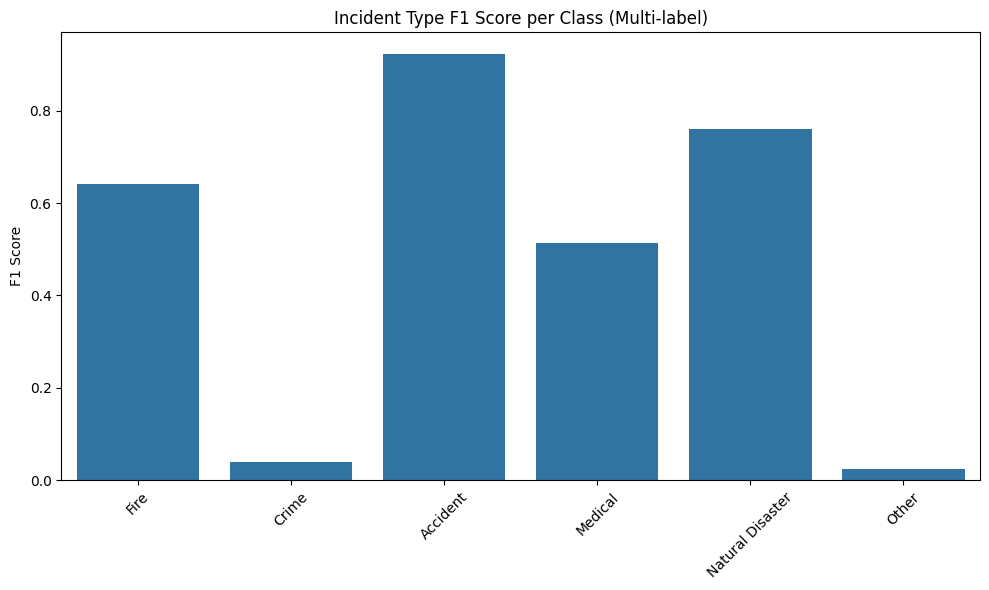

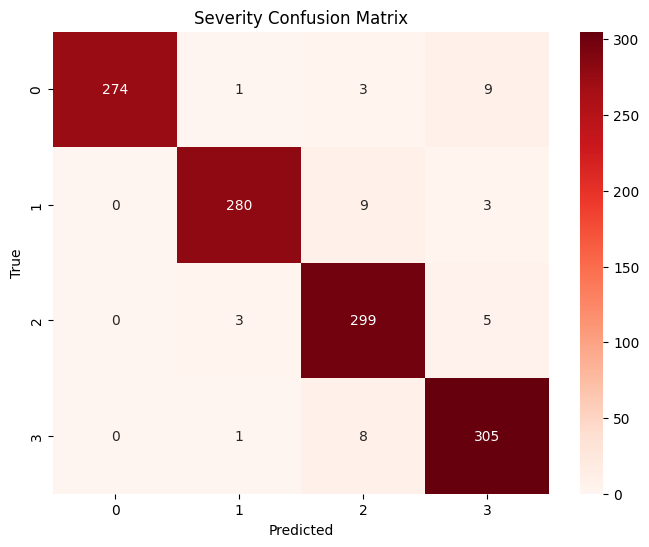

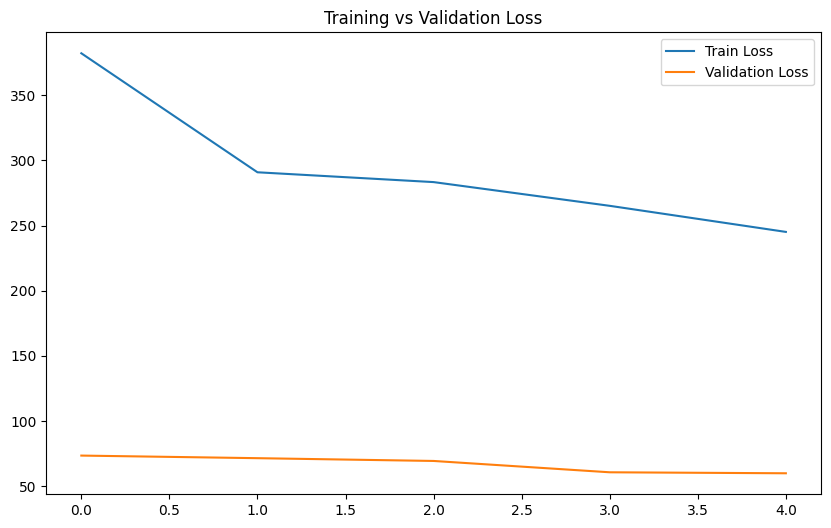

In [12]:
# --- Incident Types (multi-label) ---
y_true_types_arr = np.array(y_true_types)
y_pred_types_arr = np.array(y_pred_types)

# Per-class metrics for incident types
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_true_types_arr, y_pred_types_arr, average=None
)

incident_type_labels = {i: label for i, label in enumerate(meta["incident_type_labels"])}

plt.figure(figsize=(10,6))
sns.barplot(x=list(incident_type_labels.values()), y=f1s)
plt.title("Incident Type F1 Score per Class (Multi-label)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Severity (single-label) ---
cm_severity = confusion_matrix(y_true_severity, y_pred_severity)
plt.figure(figsize=(8,6))
sns.heatmap(cm_severity, annot=True, fmt="d", cmap="Reds")
plt.title("Severity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- Loss curves ---
plt.figure(figsize=(10,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

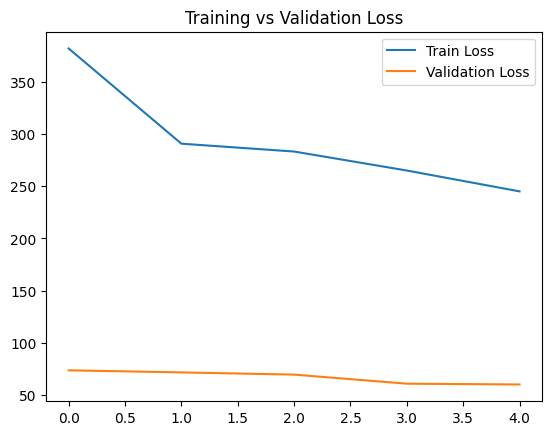

In [13]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


##STEP 6: We save the lastest trained model:
After training, we save the model’s `state_dict` back into `models/emergency_model.pt`.  
This ensures that the next time we run the notebook, we can resume from the latest trained version instead of retraining from zero.


In [14]:
# Save the trained model state
checkpoint = {
    "model_state_dict": model.state_dict(),
    "incident_type_labels": meta["incident_type_labels"],
    "severity_labels": meta["severity_labels"],
    "backbone": meta.get("backbone", "xlm-roberta-base"),
    "threshold": 0.5,
}
torch.save(checkpoint, MODEL_PATH)
print("Model checkpoint saved to:", MODEL_PATH)

Model checkpoint saved to: models/emergency_model.pt
